In [22]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [23]:
import jax
import jax.numpy as jnp
from liesel_ptm.sim.create_data import generate_data, loc_fn, scale_fn, generate_show_data
import liesel_ptm.sim.sim_ptm as sim
import liesel.goose as gs

import liesel_ptm as ptm
import plotnine as p9
import pandas as pd
import matplotlib.pyplot as plt

In [24]:
key = jax.random.PRNGKey(42)
k1, k2, k3 = jax.random.split(key, 3)
shape = ptm.sample_shape(k1, nshape=15, scale=0.4).sample

In [25]:
df = generate_data(k2, shape=shape, nobs=2000, loc_fn=loc_fn, scale_fn=scale_fn, ncov=4)
df_show = generate_show_data(shape=shape, values=(-1.0, 0.0, 1.0), index=3, loc_fn=loc_fn, scale_fn=scale_fn, ncov=4)


In [26]:
df_test = generate_data(k3, shape=shape, nobs=500, loc_fn=loc_fn, scale_fn=scale_fn, ncov=4)

In [27]:
df.head()

,y,y_std,z,z_deriv,log_prob,pdf,cdf,loc,scale,std_log_prob,...,fx2_loc,fx3_loc,fx0_scale,fx1_scale,fx2_scale,fx3_scale,x0,x1,x2,x3
0,1.710450,0.139888,0.063405,1.265990,-0.685094,0.504043,0.525278,1.570653,0.999345,-0.685750,...,-0.089474,1.000567,-1.577207,-0.326162,-0.031367,0.441307,-1.577207,0.284204,-0.894860,0.830715
1,5.935104,-0.912308,-0.952084,0.313833,-2.531066,0.079574,0.170527,8.195164,2.477299,-1.623898,...,-0.628233,3.724146,0.876524,1.359241,-0.220241,1.642559,0.876524,1.229503,-0.075516,0.133672
2,-0.018947,0.341662,0.323987,1.421010,-0.620054,0.537915,0.627026,-0.332953,0.919054,-0.704465,...,0.812300,-2.934536,-0.511153,-0.272130,0.284770,-1.294297,-0.511153,-1.703252,-0.979537,-1.665281
3,4.920756,-0.247091,-0.382167,0.502411,-1.680301,0.186318,0.351169,5.416903,2.007957,-0.983183,...,-1.876938,2.339945,1.554276,0.660704,-0.658002,1.032048,1.554276,0.907220,-0.689514,0.621528
4,1.906038,-0.215817,-0.350253,0.984465,-0.995935,0.369378,0.363073,2.132267,1.048247,-0.948816,...,0.652284,-0.873961,-1.661078,1.182971,0.228673,-0.385466,-1.661078,1.153507,-0.964763,1.321030


In [28]:
df_show.head()

,y,y_std,z,z_deriv,log_prob,pdf,cdf,loc,scale,std_log_prob,std_pdf,x0,x1,x2,x3
0,-4.435643,-4.139144,-4.000000,1.114446,-8.810580,0.000149,0.000032,-0.497307,0.951486,-8.860311,0.000142,0.0,0.0,0.0,-1.0
1,-4.399611,-4.101275,-3.959799,1.116963,-8.648327,0.000175,0.000038,-0.497307,0.951486,-8.698057,0.000167,0.0,0.0,0.0,-1.0
2,-4.363660,-4.063491,-3.919598,1.119475,-8.487702,0.000206,0.000044,-0.497307,0.951486,-8.537433,0.000196,0.0,0.0,0.0,-1.0
3,-4.327790,-4.025792,-3.879397,1.121981,-8.328705,0.000241,0.000052,-0.497307,0.951486,-8.378435,0.000230,0.0,0.0,0.0,-1.0
4,-4.292000,-3.988177,-3.839196,1.124481,-8.171331,0.000283,0.000062,-0.497307,0.951486,-8.221062,0.000269,0.0,0.0,0.0,-1.0


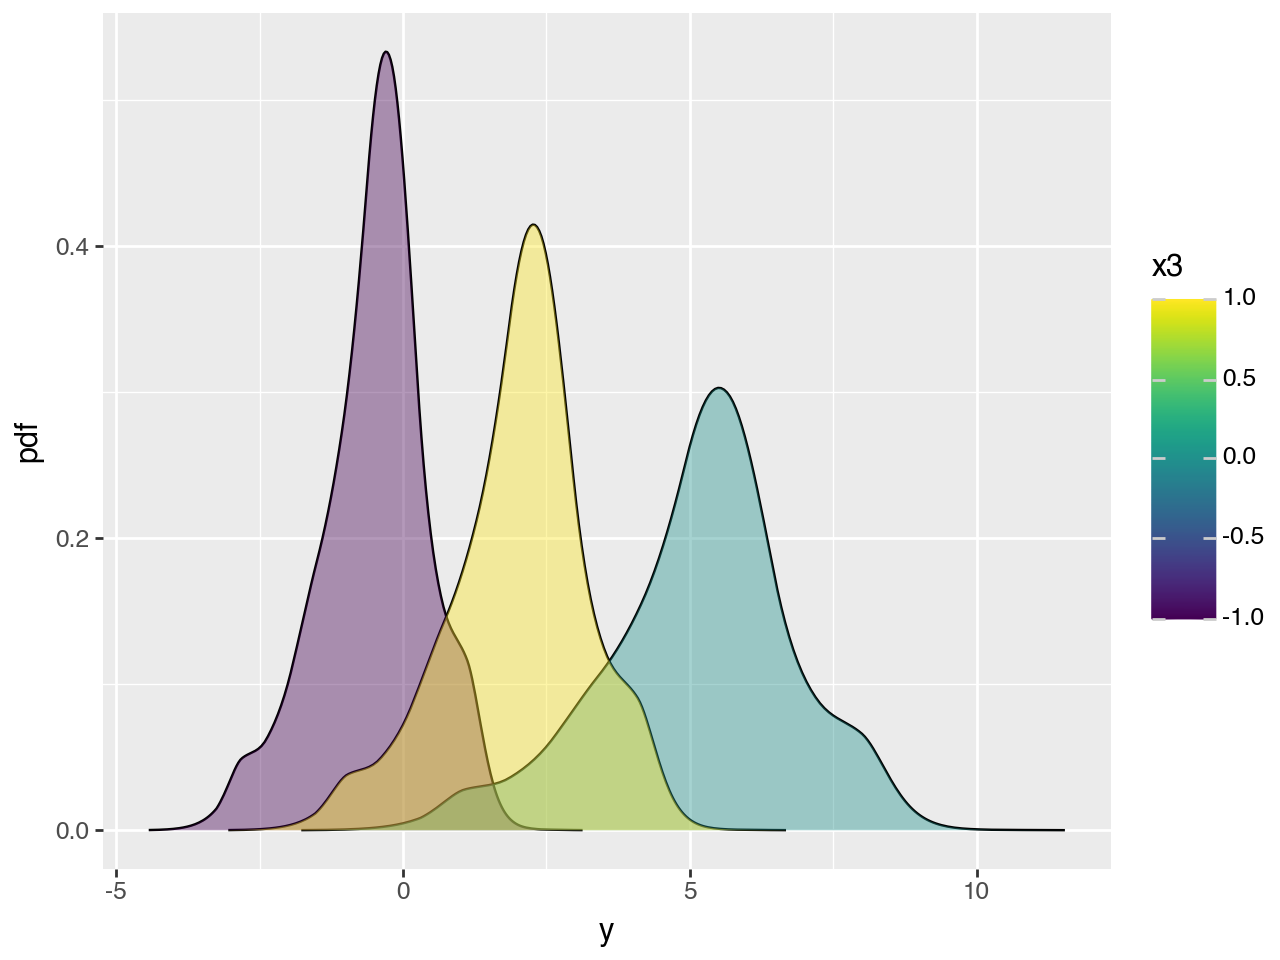

In [29]:
(
    p9.ggplot(df_show)
    + p9.aes("y", "pdf", group="x3")
    + p9.geom_line()
    + p9.geom_ribbon(p9.aes(ymin=0.0, ymax="pdf", fill="x3"), alpha=0.4)
)

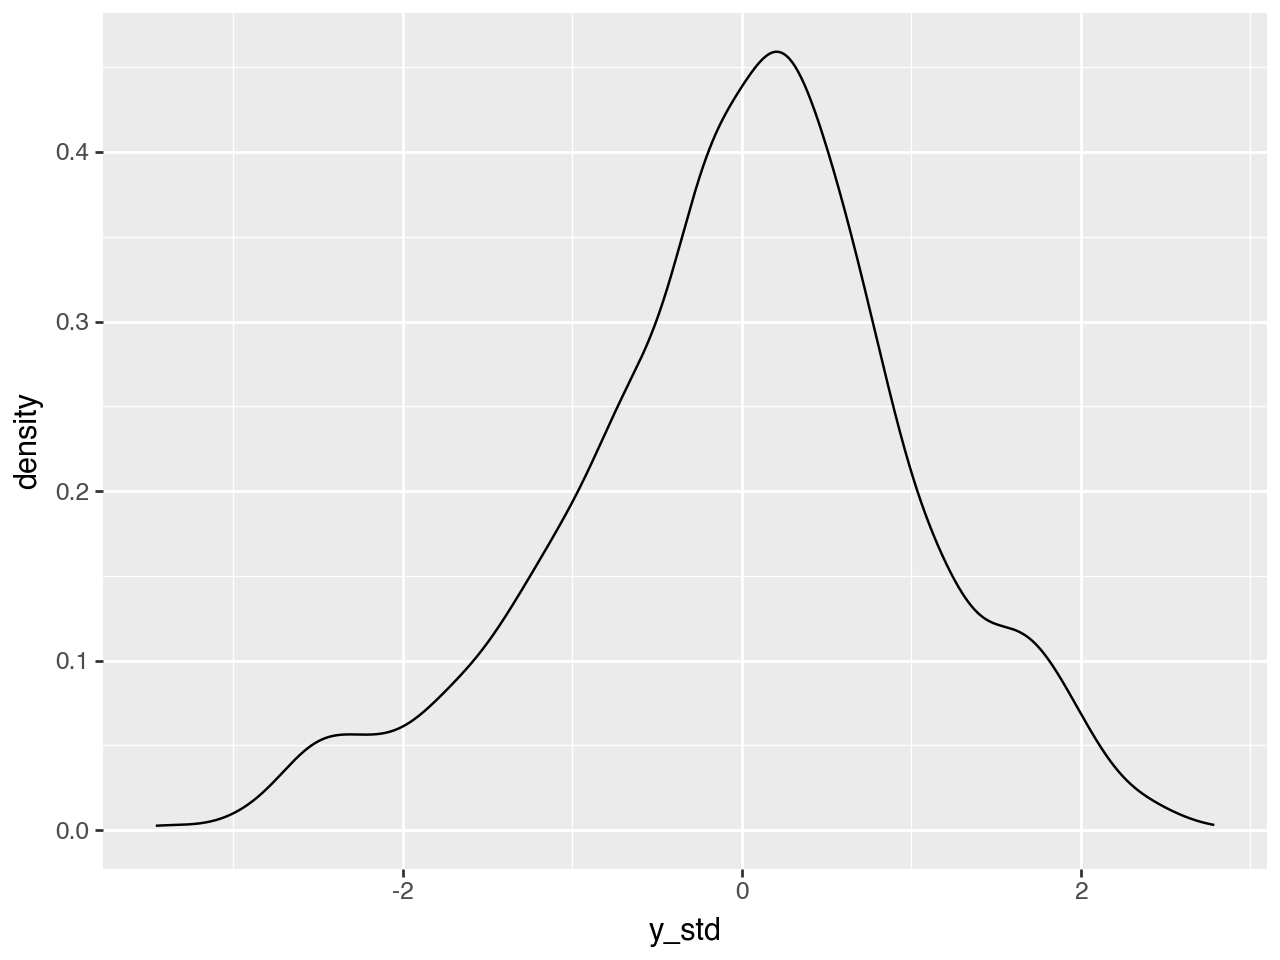

In [30]:
(
    p9.ggplot(df)
    + p9.aes("y_std")
    + p9.geom_density()
)

In [37]:
model, position = sim.model_setup(
    df, 
    prior_tau2_covariates=(ptm.VarInverseGamma, {"value": 1.0, "concentration": 1.0, "scale":0.01}),
    prior_tau2_normalization=(ptm.VarHalfCauchy, {"value": 1.0, "scale": 0.05}),
    scale_terms=True,
    nshape=30,
    shape_param_prior="RANDOM_WALK",
    scale_after_transformation=True,
    scaling_factor=ptm.TruncatedNormalOmega(name="omega"),
    optimize_knots=False
)

liesel_ptm.ptm_ls - INFO - Scaling factor supplied - turning scaling after transformation off.


In [38]:
model, position, results = model.optimize_knots()

liesel_ptm.ptm_ls - INFO - Optimizing 8 parameters.
liesel_ptm.ptm_ls - INFO - Finished optimization after 10000 iterations.
liesel_ptm.ptm_ls - INFO - Scaling factor supplied - turning scaling after transformation off.


In [39]:
results = model.build_graph(position=position)
results

liesel_ptm.ptm_ls - INFO - Optimizing parameter block #1 (len=10).
liesel_ptm.ptm_ls - INFO - Finished optimization after 10000 iterations.


(Model(193 nodes, 47 vars),
 [OptimResult(model_state={'response_log_prob': NodeState(value=Array([-0.7944802 , -2.8894076 , -0.85367495, ..., -2.427818  ,
         -1.6957345 , -0.5369853 ], dtype=float32), outdated=False, extra=None), 'response_var_value': NodeState(value=None, outdated=False, extra=None), 'response_value': NodeState(value=array([ 1.7104502 ,  5.935104  , -0.01894724, ..., -2.8351939 ,
         -5.529902  , -2.2960417 ], dtype=float32), outdated=False, extra=None), 'z_deriv': NodeState(value=Array([1.1327817 , 0.20524152, 1.7319208 , ..., 2.3089826 , 2.483333  ,
         1.4841887 ], dtype=float32), outdated=False, extra=None), 'scale_var_value': NodeState(value=None, outdated=False, extra=None), 'scale_value': NodeState(value=Array([0.9581492, 3.289966 , 0.8384114, ..., 0.7864735, 0.5630434,
         0.8083477], dtype=float32), outdated=False, extra=None), 'scale_intercept_exp_var_value': NodeState(value=None, outdated=False, extra=None), 'scale_intercept_exp_value'

In [40]:
graph, results = results

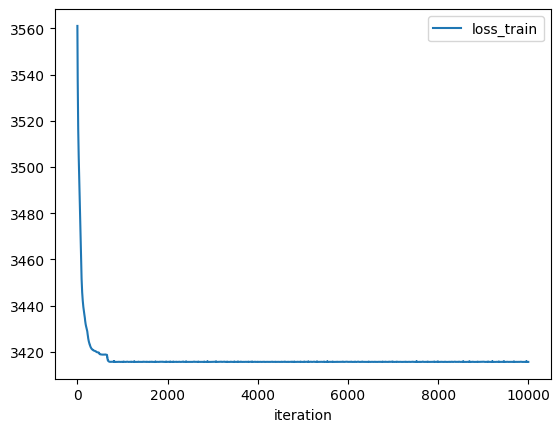

In [41]:
res1a = results[0]
ptm.history_to_df(res1a.history)[["loss_train", "iteration"]].plot("iteration")
plt.show()

In [51]:
pos = res1a.position | {"loc_intercept": model.loc_intercept.value}
pos = pos | {"scale_intercept_exp": model.scale_intercept_exp.value}
pos = pos | {"unscaled_normalization_mean": model.normalization.norm_mean.value}
pos = pos | {"unscaled_normalization_sd": model.normalization.norm_sd.value}
pos = {k: jnp.expand_dims(v, 0) for k, v in pos.items()}
pos = {k: jnp.expand_dims(v, 0) for k, v in pos.items()}

In [52]:
pred = ptm.PTMLocScalePredictions(pos, model)

In [66]:
res = pred.predict_residuals().squeeze()

In [55]:
residual = jnp.linspace(-4, 4, 301)
df_pdf = pred.summarise_transformation_by_quantiles(residual)

In [56]:
df_pdf.head()

,z_mean,z_sd,z_median,z_lo,z_hi,pdf_mean,pdf_sd,pdf_median,pdf_lo,pdf_hi,cdf_mean,cdf_sd,cdf_median,cdf_lo,cdf_hi,residual
0,-3.885293,0.0,-3.885293,-3.885293,-3.885293,0.000148,0.0,0.000148,0.000148,0.000148,0.000051,0.0,0.000051,0.000051,0.000051,-4.000000
1,-3.866647,0.0,-3.866647,-3.866647,-3.866647,0.000157,0.0,0.000157,0.000157,0.000157,0.000055,0.0,0.000055,0.000055,0.000055,-3.973333
2,-3.848265,0.0,-3.848265,-3.848265,-3.848265,0.000166,0.0,0.000166,0.000166,0.000166,0.000059,0.0,0.000059,0.000059,0.000059,-3.946667
3,-3.830148,0.0,-3.830148,-3.830148,-3.830148,0.000176,0.0,0.000176,0.000176,0.000176,0.000064,0.0,0.000064,0.000064,0.000064,-3.920000
4,-3.812294,0.0,-3.812294,-3.812294,-3.812294,0.000185,0.0,0.000185,0.000185,0.000185,0.000069,0.0,0.000069,0.000069,0.000069,-3.893333


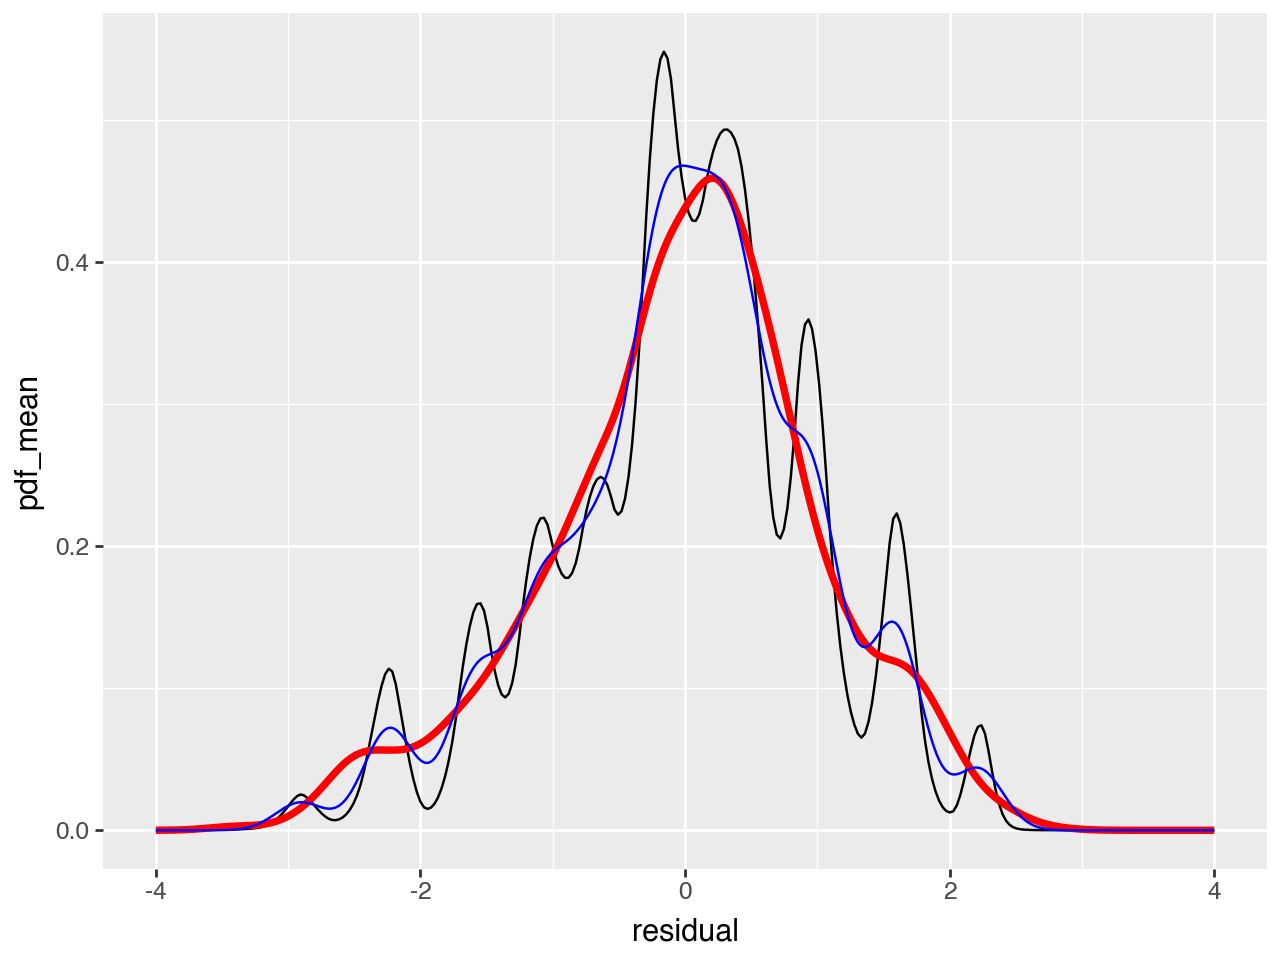

In [68]:

(
    p9.ggplot(df_pdf)
    + p9.geom_line(p9.aes("residual", "pdf_mean"))
    + p9.geom_density(p9.aes("y_std"), data = df, color="red", size=1.5)
    + p9.geom_density(
        p9.aes("res"),
        data=pd.DataFrame({"res": res}),
        color="blue"
    )
)

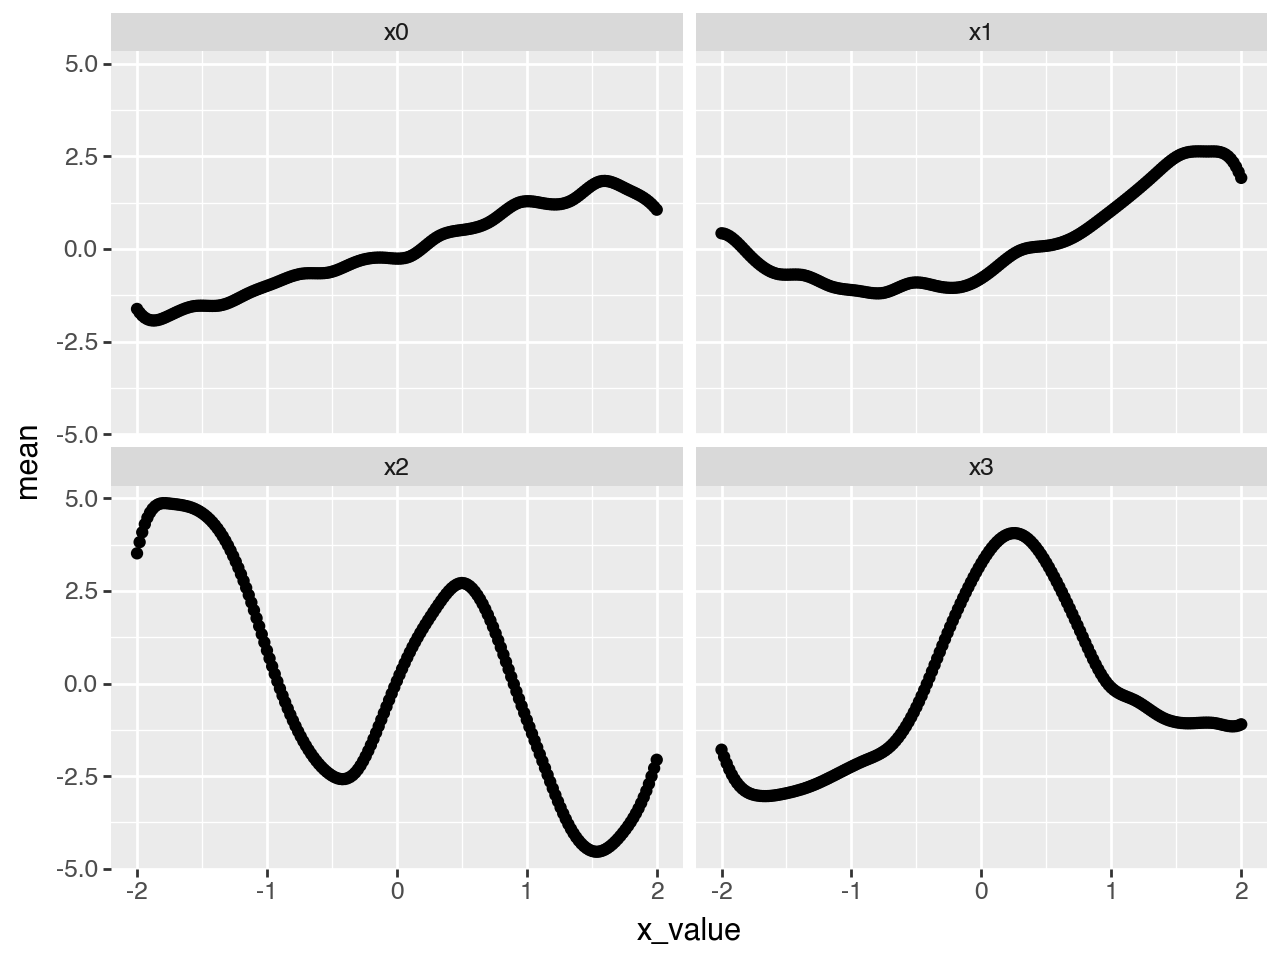

In [60]:
x0_loc = model.loc_model.x0_loc.summarise_by_quantiles(
    pos,
    x=jnp.linspace(-2, 2, 201),
    
)
x0_loc["x"] = "x0"

x1_loc = model.loc_model.x1_loc.summarise_by_quantiles(
    pos,
    x=jnp.linspace(-2, 2, 201),
    
)
x1_loc["x"] = "x1"

x2_loc = model.loc_model.x2_loc.summarise_by_quantiles(
    pos,
    x=jnp.linspace(-2, 2, 201),
    
)
x2_loc["x"] = "x2"

x3_loc = model.loc_model.x3_loc.summarise_by_quantiles(
    pos,
    x=jnp.linspace(-2, 2, 201),
    
)
x3_loc["x"] = "x3"

loc_df = pd.concat([x0_loc, x1_loc, x2_loc, x3_loc])

(
    p9.ggplot(loc_df)
    + p9.aes("x_value", "mean")
    + p9.geom_point()
    + p9.facet_wrap("~x")
)

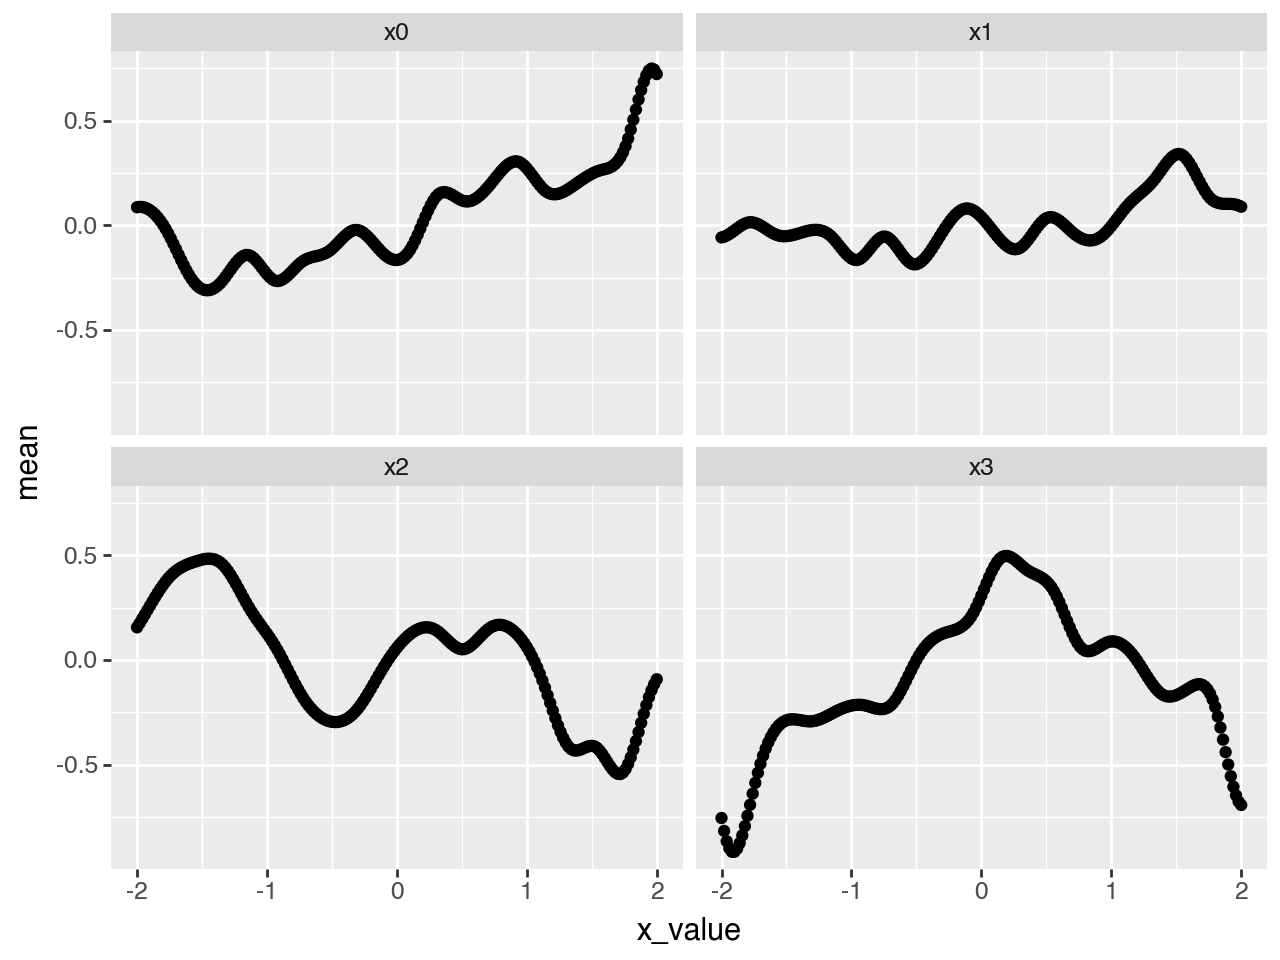

In [62]:
x0_scale = model.log_scale_model.x0_scale.summarise_by_quantiles(
    pos,
    x=jnp.linspace(-2, 2, 201),
    
)
x0_scale["x"] = "x0"

x1_scale = model.log_scale_model.x1_scale.summarise_by_quantiles(
    pos,
    x=jnp.linspace(-2, 2, 201),
    
)
x1_scale["x"] = "x1"

x2_scale = model.log_scale_model.x2_scale.summarise_by_quantiles(
    pos,
    x=jnp.linspace(-2, 2, 201),
    
)
x2_scale["x"] = "x2"

x3_scale = model.log_scale_model.x3_scale.summarise_by_quantiles(
    pos,
    x=jnp.linspace(-2, 2, 201),
    
)
x3_scale["x"] = "x3"

scale_df = pd.concat([x0_scale, x1_scale, x2_scale, x3_scale])

(
    p9.ggplot(scale_df)
    + p9.aes("x_value", "mean")
    + p9.geom_point()
    + p9.facet_wrap("~x")
)